# Project: Wrangling and Analyze Data

In [38]:
# importing all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from timeit import default_timer as timer
import tweepy
from tweepy import OAuthHandler
import re

## Data Gathering
In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [39]:
df_archive = pd.read_csv('twitter-archive-enhanced.csv')
df_archive.head(5)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,NaN,NaN,NaN,NaN


2. Use the Requests library to download the tweet image prediction (image_predictions.tsv)

In [40]:
#defining the url for the image_predictions.tsv
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'
# Send a request to download the file
response = requests.get(url)
# Save the file locally
with open('image_predictions.tsv', 'wb') as file:
    file.write(response.content)

# Read the downloaded file into a DataFrame
df_image_predictions = pd.read_csv('image_predictions.tsv', sep='\t')
df_image_predictions.head(5)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


3. Use the Tweepy library to query additional data via the Twitter API (tweet_json.txt)

In [41]:
data = []

with open('tweet_json.txt', 'r') as file:
    for line in file:
        line = line.strip()
        if line:  # skip empty lines
            data.append(json.loads(line))

df_api = pd.DataFrame(data)
df_api.head(5)

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,...,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
0,Tue Aug 01 16:23:56 +0000 2017,892420643555336193,892420643555336193,This is Phineas. He's a mystical boy. Only eve...,False,"[0, 85]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892420639486877696, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",NaN,...,39467,False,False,False,False,en,NaN,NaN,NaN,NaN
1,Tue Aug 01 00:17:27 +0000 2017,892177421306343426,892177421306343426,This is Tilly. She's just checking pup on you....,False,"[0, 138]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892177413194625024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",NaN,...,33819,False,False,False,False,en,NaN,NaN,NaN,NaN
2,Mon Jul 31 00:18:03 +0000 2017,891815181378084864,891815181378084864,This is Archie. He is a rare Norwegian Pouncin...,False,"[0, 121]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891815175371796480, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",NaN,...,25461,False,False,False,False,en,NaN,NaN,NaN,NaN
3,Sun Jul 30 15:58:51 +0000 2017,891689557279858688,891689557279858688,This is Darla. She commenced a snooze mid meal...,False,"[0, 79]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891689552724799489, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",NaN,...,42908,False,False,False,False,en,NaN,NaN,NaN,NaN
4,Sat Jul 29 16:00:24 +0000 2017,891327558926688256,891327558926688256,This is Franklin. He would like you to stop ca...,False,"[0, 138]","{'hashtags': [{'text': 'BarkWeek', 'indices': ...","{'media': [{'id': 891327551943041024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",NaN,...,41048,False,False,False,False,en,NaN,NaN,NaN,NaN


imported every file as pandas dataframes

## Assessing Data
In this section, detect and document at least **eight (8) quality issues and two (2) tidiness issue**. You must use **both** visual assessment
programmatic assessement to assess the data.

**Note:** pay attention to the following key points when you access the data.

* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This [unique rating system](http://knowyourmeme.com/memes/theyre-good-dogs-brent) is a big part of the popularity of WeRateDogs.
* You do not need to gather the tweets beyond August 1st, 2017. You can, but note that you won't be able to gather the image predictions for these tweets since you don't have access to the algorithm used.



### Getting information and description on every dataframe 

In [42]:
# getting information and desciptionabout the dataframes
df_archive.info()
df_archive.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        1611 non-null   object 
 13  doggo                       97 no

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,retweeted_status_id,retweeted_status_user_id,rating_numerator,rating_denominator
count,2.356000e+03,7.800000e+01,7.800000e+01,1.810000e+02,1.810000e+02,2356.000000,2356.000000
mean,7.427716e+17,7.455079e+17,2.014171e+16,7.720400e+17,1.241698e+16,13.126486,10.455433
std,6.856705e+16,7.582492e+16,1.252797e+17,6.236928e+16,9.599254e+16,45.876648,6.745237
min,6.660209e+17,6.658147e+17,1.185634e+07,6.661041e+17,7.832140e+05,0.000000,0.000000
25%,6.783989e+17,6.757419e+17,3.086374e+08,7.186315e+17,4.196984e+09,10.000000,10.000000
50%,7.196279e+17,7.038708e+17,4.196984e+09,7.804657e+17,4.196984e+09,11.000000,10.000000
75%,7.993373e+17,8.257804e+17,4.196984e+09,8.203146e+17,4.196984e+09,12.000000,10.000000
max,8.924206e+17,8.862664e+17,8.405479e+17,8.874740e+17,7.874618e+17,1776.000000,170.000000


In [43]:
# getting information and desciptionabout the dataframes
df_api.info()
df_api.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   created_at                     2354 non-null   object 
 1   id                             2354 non-null   int64  
 2   id_str                         2354 non-null   object 
 3   full_text                      2354 non-null   object 
 4   truncated                      2354 non-null   bool   
 5   display_text_range             2354 non-null   object 
 6   entities                       2354 non-null   object 
 7   extended_entities              2073 non-null   object 
 8   source                         2354 non-null   object 
 9   in_reply_to_status_id          78 non-null     float64
 10  in_reply_to_status_id_str      78 non-null     object 
 11  in_reply_to_user_id            78 non-null     float64
 12  in_reply_to_user_id_str        78 non-null     o

,id,in_reply_to_status_id,in_reply_to_user_id,retweet_count,favorite_count,quoted_status_id
count,2.354000e+03,7.800000e+01,7.800000e+01,2354.000000,2354.000000,2.900000e+01
mean,7.426978e+17,7.455079e+17,2.014171e+16,3164.797366,8080.968564,8.162686e+17
std,6.852812e+16,7.582492e+16,1.252797e+17,5284.770364,11814.771334,6.164161e+16
min,6.660209e+17,6.658147e+17,1.185634e+07,0.000000,0.000000,6.721083e+17
25%,6.783975e+17,6.757419e+17,3.086374e+08,624.500000,1415.000000,7.888183e+17
50%,7.194596e+17,7.038708e+17,4.196984e+09,1473.500000,3603.500000,8.340867e+17
75%,7.993058e+17,8.257804e+17,4.196984e+09,3652.000000,10122.250000,8.664587e+17
max,8.924206e+17,8.862664e+17,8.405479e+17,79515.000000,132810.000000,8.860534e+17


In [44]:
# getting information and desciptionabout the dataframes
df_image_predictions.info()
df_image_predictions.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


,tweet_id,img_num,p1_conf,p2_conf,p3_conf
count,2.075000e+03,2075.000000,2075.000000,2.075000e+03,2.075000e+03
mean,7.384514e+17,1.203855,0.594548,1.345886e-01,6.032417e-02
std,6.785203e+16,0.561875,0.271174,1.006657e-01,5.090593e-02
min,6.660209e+17,1.000000,0.044333,1.011300e-08,1.740170e-10
25%,6.764835e+17,1.000000,0.364412,5.388625e-02,1.622240e-02
50%,7.119988e+17,1.000000,0.588230,1.181810e-01,4.944380e-02
75%,7.932034e+17,1.000000,0.843855,1.955655e-01,9.180755e-02
max,8.924206e+17,4.000000,1.000000,4.880140e-01,2.734190e-01


- found nulls in df_archive and df_api only
- no duplicated values

### Getting the unique values in specific fields which could have invalid values

In [45]:
# looking for any invalid values in the name column
df_archive['name'].unique()

array(['Phineas', 'Tilly', 'Archie', 'Darla', 'Franklin', nan, 'Jax',
       'Zoey', 'Cassie', 'Koda', 'Bruno', 'Ted', 'Stuart', 'Oliver',
       'Jim', 'Zeke', 'Ralphus', 'Canela', 'Gerald', 'Jeffrey', 'such',
       'Maya', 'Mingus', 'Derek', 'Roscoe', 'Waffles', 'Jimbo', 'Maisey',
       'Lilly', 'Earl', 'Lola', 'Kevin', 'Yogi', 'Noah', 'Bella',
       'Grizzwald', 'Rusty', 'Gus', 'Stanley', 'Alfy', 'Koko', 'Rey',
       'Gary', 'a', 'Elliot', 'Louis', 'Jesse', 'Romeo', 'Bailey',
       'Duddles', 'Jack', 'Emmy', 'Steven', 'Beau', 'Snoopy', 'Shadow',
       'Terrance', 'Aja', 'Penny', 'Dante', 'Nelly', 'Ginger', 'Benedict',
       'Venti', 'Goose', 'Nugget', 'Cash', 'Coco', 'Jed', 'Sebastian',
       'Walter', 'Sierra', 'Monkey', 'Harry', 'Kody', 'Lassie', 'Rover',
       'Napolean', 'Dawn', 'Boomer', 'Cody', 'Rumble', 'Clifford',
       'quite', 'Dewey', 'Scout', 'Gizmo', 'Cooper', 'Harold', 'Shikha',
       'Jamesy', 'Lili', 'Sammy', 'Meatball', 'Paisley', 'Albus',
       'Neptune

- Found 1 invalid value in `df_archive` in the `name` field which had the value `a` for a dog which is invalid</br>
there was no need to get the unique values of the other dataframes 

### Checking the dataframes validity

In [46]:
#printing the timestamp column to make sure that the time dosent pass august first
df_archive['timestamp']

0       2017-08-01 16:23:56 +0000
1       2017-08-01 00:17:27 +0000
2       2017-07-31 00:18:03 +0000
3       2017-07-30 15:58:51 +0000
4       2017-07-29 16:00:24 +0000
                  ...            
2351    2015-11-16 00:24:50 +0000
2352    2015-11-16 00:04:52 +0000
2353    2015-11-15 23:21:54 +0000
2354    2015-11-15 23:05:30 +0000
2355    2015-11-15 22:32:08 +0000
Name: timestamp, Length: 2356, dtype: object

In [47]:
#cheking the df_api source field first record
df_api['source'].iloc[0]

'<a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>'

In [48]:
#cheking the entity field first record
df_api['entities'].iloc[1]

{'hashtags': [],
 'symbols': [],
 'user_mentions': [],
 'urls': [],
 'media': [{'id': 892177413194625024,
   'id_str': '892177413194625024',
   'indices': [139, 162],
   'media_url': 'http://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg',
   'media_url_https': 'https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg',
   'url': 'https://t.co/0Xxu71qeIV',
   'display_url': 'pic.twitter.com/0Xxu71qeIV',
   'expanded_url': 'https://twitter.com/dog_rates/status/892177421306343426/photo/1',
   'type': 'photo',
   'sizes': {'large': {'w': 1407, 'h': 1600, 'resize': 'fit'},
    'thumb': {'w': 150, 'h': 150, 'resize': 'crop'},
    'small': {'w': 598, 'h': 680, 'resize': 'fit'},
    'medium': {'w': 1055, 'h': 1200, 'resize': 'fit'}}}]}

- found addtional '+0000' in every record in the `timestamp` field
- addtional html tags in the `source` field
- in the `entities` field in each record the 'display_url' is missing 'https://'

In [49]:
df_archive['text'].duplicated().sum()

np.int64(0)

______________________________________________________________________________________________________________________________________

### Quality issues
1.null values in the `df_archive` dataframe `in_reply_to_status_id `, `in_reply_to_user_id`, `retweeted_status_id`, `retweeted_status_user_id`, `retweeted_status_timestamp`, `expanded_urls`, `name`, `doggo`, `floofer`, `pupper`, `puppo` and in the `df_api`: `extended_entities`, reply to status details fields, `geo`, `coordinates`, `place`, `contributors` and the sensitive fields, `retweeted_status` and the quoted status fields

2.invalid value, a dog named `"a"` in the `name` field in `df_archive` dataframe 

3.the dogs life ages in the `df_archive` is set to object dtype

4.in `df_api` in the `entities` field the 'display_url' is missing "https://"

5.the prediction fields in the `df_image_prediction` should be out of 100

6.there's no need for the `id_string` field int he `df_api` dataframe

7.dtype for `timestamp` field in `df_archive` is wrong 

8.wrong dtype for `in_reply_to_status_id`, `in_reply_to_user_id` which is float in the `df_archive`

### Tidiness issues
1.Dog stage spread across multiple columns(doggo, floofer, pupper and puppo)

2.Tweet data spread across three DataFrames

_____________________________________________________________________________________________________________________________________________

## Cleaning Data
In this section, clean **all** of the issues you documented while assessing. 

**Note:** Make a copy of the original data before cleaning. Cleaning includes merging individual pieces of data according to the rules of [tidy data](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html). The result should be a high-quality and tidy master pandas DataFrame (or DataFrames, if appropriate).

In [50]:
# Make copies of original pieces of data
copied_archive = df_archive.copy()
copied_api = df_api.copy()
copied_predictions = df_image_predictions.copy()

making a copy of every dataframe

___________________________________________________________________________________________________________________________________________

### Issue #1: Missing values

#### Define: lost data or unfouned data

#### Code

In [51]:
# Keep only original tweets
df_archive = df_archive[df_archive['retweeted_status_id'].isnull() & 
                        df_archive['retweeted_status_user_id'].isnull() & 
                        df_archive['retweeted_status_timestamp'].isnull()]
#making a function to remove nan values from the dataframes
def fill_nan(df):
    for column in df.columns:
        dtype = df[column].dtype
        if pd.api.types.is_numeric_dtype(dtype):
            df[column] = df[column].fillna(0)
        elif pd.api.types.is_string_dtype(dtype):
            df[column] = df[column].fillna('')
        elif pd.api.types.is_datetime64_any_dtype(dtype):
            df[column] = df[column].fillna(pd.Timestamp('9999-12-30'))
        elif pd.api.types.is_categorical_dtype(dtype):
            df[column] = df[column].fillna(df[column].mode().iloc[0])
        else:
            df[column] = df[column].fillna('unknown')
    return df
#dropping the retweeted columns from the archive dataframe
df_archive = df_archive.drop(columns=['retweeted_status_id', 'retweeted_status_user_id', 'retweeted_status_timestamp'])
#using the function to fill the nan values in the dataframes
copied_archive = fill_nan(copied_archive)
copied_api = fill_nan(copied_api)
copied_predictions = fill_nan(copied_predictions)



#### Test

In [52]:
#checking if the nan values are removed from the dataframes
copied_archive.isnull().sum().sum()
copied_api.isnull().sum().sum()
copied_predictions.isnull().sum().sum()

np.int64(0)

### Issue #2: Invalid values

#### Define values that are wrong or inaccurate

#### Code

In [53]:
#removing the a from the name column
copied_archive = copied_archive[copied_archive['name'] != 'a']

#### Test

In [54]:
#cheking if its removed
copied_archive['name'].unique()

array(['Phineas', 'Tilly', 'Archie', 'Darla', 'Franklin', '', 'Jax',
       'Zoey', 'Cassie', 'Koda', 'Bruno', 'Ted', 'Stuart', 'Oliver',
       'Jim', 'Zeke', 'Ralphus', 'Canela', 'Gerald', 'Jeffrey', 'such',
       'Maya', 'Mingus', 'Derek', 'Roscoe', 'Waffles', 'Jimbo', 'Maisey',
       'Lilly', 'Earl', 'Lola', 'Kevin', 'Yogi', 'Noah', 'Bella',
       'Grizzwald', 'Rusty', 'Gus', 'Stanley', 'Alfy', 'Koko', 'Rey',
       'Gary', 'Elliot', 'Louis', 'Jesse', 'Romeo', 'Bailey', 'Duddles',
       'Jack', 'Emmy', 'Steven', 'Beau', 'Snoopy', 'Shadow', 'Terrance',
       'Aja', 'Penny', 'Dante', 'Nelly', 'Ginger', 'Benedict', 'Venti',
       'Goose', 'Nugget', 'Cash', 'Coco', 'Jed', 'Sebastian', 'Walter',
       'Sierra', 'Monkey', 'Harry', 'Kody', 'Lassie', 'Rover', 'Napolean',
       'Dawn', 'Boomer', 'Cody', 'Rumble', 'Clifford', 'quite', 'Dewey',
       'Scout', 'Gizmo', 'Cooper', 'Harold', 'Shikha', 'Jamesy', 'Lili',
       'Sammy', 'Meatball', 'Paisley', 'Albus', 'Neptune', 'Quinn',
 

### Issue #3: inavlid dtype for dog ages

#### Define: the dogs ages levels is set to object

#### Code

In [55]:
#changing the doggo field dtype to bool
copied_archive['doggo'] = copied_archive['doggo'].astype(bool)
#changing the floofer field dtype to bool
copied_archive['floofer'] = copied_archive['floofer'].astype(bool)
#changing the pupper field dtype to bool
copied_archive['pupper'] = copied_archive['pupper'].astype(bool)
#changing the puppo field dtype to bool
copied_archive['puppo'] = copied_archive['puppo'].astype(bool)

#### Test

In [56]:
copied_archive.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2301 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2301 non-null   int64  
 1   in_reply_to_status_id       2301 non-null   float64
 2   in_reply_to_user_id         2301 non-null   float64
 3   timestamp                   2301 non-null   object 
 4   source                      2301 non-null   object 
 5   text                        2301 non-null   object 
 6   retweeted_status_id         2301 non-null   float64
 7   retweeted_status_user_id    2301 non-null   float64
 8   retweeted_status_timestamp  2301 non-null   object 
 9   expanded_urls               2301 non-null   object 
 10  rating_numerator            2301 non-null   int64  
 11  rating_denominator          2301 non-null   int64  
 12  name                        2301 non-null   object 
 13  doggo                       2301 non-n

### Issue #4: URL missing schema

#### Define: the link is missing https:// at the begging

#### Code

In [57]:
#making a funcion to add the https:// to the display_url in the entity field
def fix_display_url(entity):
    if 'media' in entity and isinstance(entity['media'], list):
        for media_item in entity['media']:
            if 'display_url' in media_item:
                # If display_url doesn't start with http, fix it
                if not media_item['display_url'].startswith('http'):
                    media_item['display_url'] = 'https://' + media_item['display_url']
    return entity
# Apply the function to the 'entities' column
copied_api['entities'] = copied_api['entities'].apply(fix_display_url)


#### Test

In [58]:
copied_api['entities'].iloc[0]

{'hashtags': [],
 'symbols': [],
 'user_mentions': [],
 'urls': [],
 'media': [{'id': 892420639486877696,
   'id_str': '892420639486877696',
   'indices': [86, 109],
   'media_url': 'http://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg',
   'media_url_https': 'https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg',
   'url': 'https://t.co/MgUWQ76dJU',
   'display_url': 'https://pic.twitter.com/MgUWQ76dJU',
   'expanded_url': 'https://twitter.com/dog_rates/status/892420643555336193/photo/1',
   'type': 'photo',
   'sizes': {'large': {'w': 540, 'h': 528, 'resize': 'fit'},
    'thumb': {'w': 150, 'h': 150, 'resize': 'crop'},
    'small': {'w': 540, 'h': 528, 'resize': 'fit'},
    'medium': {'w': 540, 'h': 528, 'resize': 'fit'}}}]}

### Issue #5: Prediction confidence not in percentage

#### Define: the machien's prediciton confidence not in precentage

#### Code

In [59]:
#multiplying all the confidence values by 100 and rounding them to 2 decimal places
copied_predictions['p1_conf'] = copied_predictions['p1_conf'].multiply(100).round(2)
copied_predictions['p2_conf'] = copied_predictions['p2_conf'].multiply(100).round(2)
copied_predictions['p3_conf'] = copied_predictions['p3_conf'].multiply(100).round(2)


#### Test

In [60]:
copied_predictions.head(1)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,46.51,True,collie,15.67,True,Shetland_sheepdog,6.14,True


### Issue #6: additonal field

#### Define: there's an id field and id_str field 

#### Code

In [61]:
#dropping the id_str column from the copied_api dataframe
copied_api = copied_api.drop(columns=['id_str'])

#### Test

In [62]:
#cheking the copied_api dataframe after dropping the id_str column
copied_api.head()

,created_at,id,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,in_reply_to_status_id_str,...,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
0,Tue Aug 01 16:23:56 +0000 2017,892420643555336193,This is Phineas. He's a mystical boy. Only eve...,False,"[0, 85]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892420639486877696, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",0.0,,...,39467,False,False,False,False,en,,0.0,,
1,Tue Aug 01 00:17:27 +0000 2017,892177421306343426,This is Tilly. She's just checking pup on you....,False,"[0, 138]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892177413194625024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",0.0,,...,33819,False,False,False,False,en,,0.0,,
2,Mon Jul 31 00:18:03 +0000 2017,891815181378084864,This is Archie. He is a rare Norwegian Pouncin...,False,"[0, 121]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891815175371796480, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",0.0,,...,25461,False,False,False,False,en,,0.0,,
3,Sun Jul 30 15:58:51 +0000 2017,891689557279858688,This is Darla. She commenced a snooze mid meal...,False,"[0, 79]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891689552724799489, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",0.0,,...,42908,False,False,False,False,en,,0.0,,
4,Sat Jul 29 16:00:24 +0000 2017,891327558926688256,This is Franklin. He would like you to stop ca...,False,"[0, 138]","{'hashtags': [{'text': 'BarkWeek', 'indices': ...","{'media': [{'id': 891327551943041024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",0.0,,...,41048,False,False,False,False,en,,0.0,,


### Issue #7: wrong dtype for `timestamp`

#### Define the timestamp filed's dtype should be datetime

#### Code

In [63]:
# changing the timestamp column to datetime format
copied_archive['timestamp'] = pd.to_datetime(copied_archive['timestamp'])

#### Test

In [64]:
#cheking the timestamp column's dtype
copied_archive['timestamp'].dtype


datetime64[ns, UTC]

### Issue #8: wrong dtype for ids

#### Define: the ids in the df_archive is formated as float which should be integer

#### Code

In [65]:
#changing the ids to integers
copied_archive['in_reply_to_status_id'] = copied_archive['in_reply_to_status_id'].astype('Int64')
copied_archive['in_reply_to_user_id'] = copied_archive['in_reply_to_user_id'].astype('Int64')

#### Test

In [66]:
#making sure that the ids are changed to integers
copied_archive['in_reply_to_status_id'].dtype
copied_archive['in_reply_to_user_id'].dtype

Int64Dtype()

### Issue #9: multiple dog stages in diffrent columns

#### Define: the dogs satges is spread across 4 diffrent column while it could be merged in one

#### Code

In [67]:
# Combine the four dog stage columns into a single column
copied_archive['dog_stage'] = copied_archive[['doggo', 'floofer', 'pupper', 'puppo']].apply(
	lambda x: ', '.join(x[x == True].index), axis=1
)

# Replace empty values with "unknown" instead of NaN
copied_archive['dog_stage'] = copied_archive['dog_stage'].replace('', 'unknown')

# Drop the original columns
copied_archive = copied_archive.drop(columns=['doggo', 'floofer', 'pupper', 'puppo'])


#### Test

In [68]:
copied_archive.head(1)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,dog_stage
0,892420643555336193,0,0,2017-08-01 16:23:56+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,0.0,0.0,,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,unknown


### Issue #5: Tweet data is spread across the 3 dataframes

#### Define: all Tweet data should be combied into one dataframe

#### Code

In [69]:
# Rename 'tweet_id' to 'id' in the DataFrames where needed
copied_archive = copied_archive.rename(columns={'tweet_id': 'id'})
copied_api = copied_api.rename(columns={'tweet_id': 'id'})
copied_predictions = copied_predictions.rename(columns={'tweet_id': 'id'})  # Only if needed

# mering the three dataframes into one
twitter_archive_master = copied_archive.merge(copied_api, on='id', how='inner')
twitter_archive_master = twitter_archive_master.merge(copied_predictions, on='id', how='inner')


#### Test

In [70]:
twitter_archive_master.head()

,id,in_reply_to_status_id_x,in_reply_to_user_id_x,timestamp,source_x,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,892420643555336193,0,0,2017-08-01 16:23:56+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,0.0,0.0,,https://twitter.com/dog_rates/status/892420643...,...,1,orange,9.70,False,bagel,8.59,False,banana,7.61,False
1,892177421306343426,0,0,2017-08-01 00:17:27+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,0.0,0.0,,https://twitter.com/dog_rates/status/892177421...,...,1,Chihuahua,32.36,True,Pekinese,9.06,True,papillon,6.90,True
2,891815181378084864,0,0,2017-07-31 00:18:03+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,0.0,0.0,,https://twitter.com/dog_rates/status/891815181...,...,1,Chihuahua,71.60,True,malamute,7.83,True,kelpie,3.14,True
3,891689557279858688,0,0,2017-07-30 15:58:51+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,0.0,0.0,,https://twitter.com/dog_rates/status/891689557...,...,1,paper_towel,17.03,False,Labrador_retriever,16.81,True,spatula,4.08,False
4,891327558926688256,0,0,2017-07-29 16:00:24+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,0.0,0.0,,https://twitter.com/dog_rates/status/891327558...,...,2,basset,55.57,True,English_springer,22.58,True,German_short-haired_pointer,17.52,True


- fixed every quality issues in the assesment
- fixed every tideness issue in the assesment

## Storing Data
Save gathered, assessed, and cleaned master dataset to a CSV file named "twitter_archive_master.csv".

In [71]:
# Save to CSV
twitter_archive_master.to_csv('twitter_archive_master.csv', index=False)



## Analyzing and Visualizing Data
In this section, analyze and visualize your wrangled data. You must produce at least **three (3) insights and one (1) visualization.**

### Insights:
1.Higher Ratings means Higher Engagement

2.Dog Stage Popularity

3.Breed Predictions with High Confidence

### Visualization

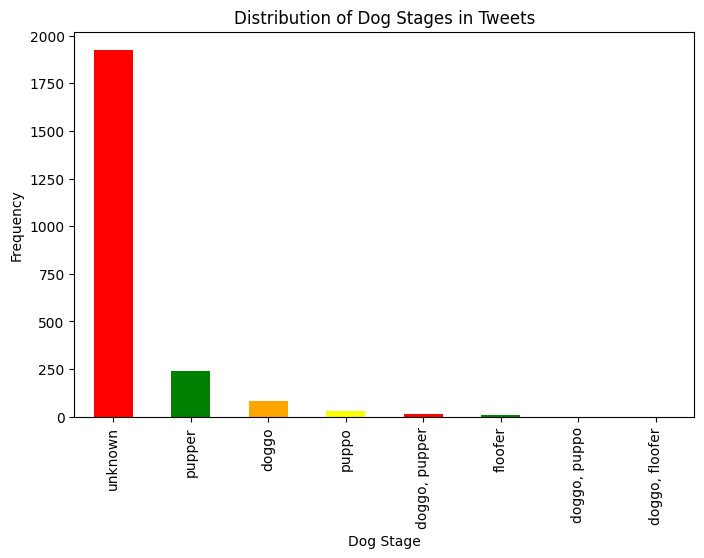

In [72]:
# Count occurrences of each dog stage
dog_stage_counts = copied_archive['dog_stage'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 5))
dog_stage_counts.plot(kind='bar', color=['red', 'green', 'orange', 'yellow'])

# Add labels and title
plt.xlabel('Dog Stage')
plt.ylabel('Frequency')
plt.title('Distribution of Dog Stages in Tweets')

# Show the plot
plt.show()
